In [18]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [19]:
import pandas as pd
from sklearn.model_selection import train_test_split


df = pd.read_csv('/content/drive/MyDrive/Group Work_Pipeline_Last.csv')


X = df.drop(columns=['is_fit'])
y = df['is_fit']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(" Data loaded and split again!")
print("Train:", X_train.shape, " Test:", X_test.shape)


 Data loaded and split again!
Train: (1562, 9)  Test: (391, 9)


In [20]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score


Model 1

In [21]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report


rf1 = RandomForestClassifier(random_state=42)
rf1.fit(X_train, y_train)
y_pred1 = rf1.predict(X_test)

acc1 = accuracy_score(y_test, y_pred1)
f11 = f1_score(y_test, y_pred1)
print("=== MODEL 1 (Default Parameters) ===")
print("Accuracy:", acc1)
print("F1 Score:", f11)
print("\nClassification Report:\n", classification_report(y_test, y_pred1))


=== MODEL 1 (Default Parameters) ===
Accuracy: 0.7595907928388747
F1 Score: 0.6618705035971223

Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.87      0.81       235
           1       0.75      0.59      0.66       156

    accuracy                           0.76       391
   macro avg       0.76      0.73      0.74       391
weighted avg       0.76      0.76      0.75       391



In [22]:

train_acc1 = rf1.score(X_train, y_train)
test_acc1  = rf1.score(X_test, y_test)

print("Train Accuracy:", train_acc1)
print("Test Accuracy:", test_acc1)


Train Accuracy: 1.0
Test Accuracy: 0.7595907928388747


Model 2

In [23]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score

rf_tuned1 = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_split=5,
    min_samples_leaf=4,
    random_state=42
)

rf_tuned1.fit(X_train, y_train)
y_pred_tuned1 = rf_tuned1.predict(X_test)

print("=== MODEL 2 (Reduced Complexity) ===")
print("Train Accuracy:", rf_tuned1.score(X_train, y_train))
print("Test Accuracy:", rf_tuned1.score(X_test, y_test))
print("F1 Score:", f1_score(y_test, y_pred_tuned1))


=== MODEL 2 (Reduced Complexity) ===
Train Accuracy: 0.9078104993597952
Test Accuracy: 0.7519181585677749
F1 Score: 0.6548042704626335


Model 3

In [24]:

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

def diagnose(train_acc, test_acc, gap_thresh=0.08):
    gap = train_acc - test_acc
    if train_acc < 0.8 and test_acc < 0.8:
        return f"Underfitting (both low). Gap={gap:.3f}"
    if gap > gap_thresh:
        return f"Overfitting (train >> test). Gap={gap:.3f}"
    return f"Balanced/OK. Gap={gap:.3f}"

rf_balanced = RandomForestClassifier(
    n_estimators=500,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)
rf_balanced.fit(X_train, y_train)

y_pred_bal = rf_balanced.predict(X_test)

train_acc_bal = rf_balanced.score(X_train, y_train)
test_acc_bal  = rf_balanced.score(X_test, y_test)
f1_bal        = f1_score(y_test, y_pred_bal)

print("=== MODEL 3 (Balanced) ===")
print("Train Accuracy:", train_acc_bal)
print("Test Accuracy:",  test_acc_bal)
print("F1 Score:",       f1_bal)
print("Diagnosis:",      diagnose(train_acc_bal, test_acc_bal))
print("\nClassification Report:\n", classification_report(y_test, y_pred_bal, zero_division=0))


best_candidate = rf_balanced

=== MODEL 3 (Balanced) ===
Train Accuracy: 0.9622279129321383
Test Accuracy: 0.7570332480818415
F1 Score: 0.6619217081850534
Diagnosis: Overfitting (train >> test). Gap=0.205

Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.86      0.81       235
           1       0.74      0.60      0.66       156

    accuracy                           0.76       391
   macro avg       0.75      0.73      0.74       391
weighted avg       0.76      0.76      0.75       391



Model 4

In [25]:

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report


def diagnose(train_acc, test_acc, gap_thresh=0.08):
    gap = train_acc - test_acc
    if train_acc < 0.8 and test_acc < 0.8:
        return f"Underfitting (both low). Gap={gap:.3f}"
    if gap > gap_thresh:
        return f"Overfitting (train >> test). Gap={gap:.3f}"
    return f"Balanced/OK. Gap={gap:.3f}"

rf_strong = RandomForestClassifier(
    n_estimators=600,
    max_depth=7,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42
)

rf_strong.fit(X_train, y_train)
y_pred_strong = rf_strong.predict(X_test)

train_acc_strong = rf_strong.score(X_train, y_train)
test_acc_strong  = rf_strong.score(X_test, y_test)
f1_strong        = f1_score(y_test, y_pred_strong)

print("=== MODEL 4 (Stronger Regularization + Class Balance) ===")
print("Train Accuracy:", train_acc_strong)
print("Test Accuracy:",  test_acc_strong)
print("F1 Score:",       f1_strong)
print("Diagnosis:",      diagnose(train_acc_strong, test_acc_strong))
print("\nClassification Report:\n", classification_report(y_test, y_pred_strong, zero_division=0))


candidate_model = rf_strong
candidate_preds  = y_pred_strong


=== MODEL 4 (Stronger Regularization + Class Balance) ===
Train Accuracy: 0.8764404609475032
Test Accuracy: 0.7595907928388747
F1 Score: 0.6948051948051948
Diagnosis: Overfitting (train >> test). Gap=0.117

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.81      0.80       235
           1       0.70      0.69      0.69       156

    accuracy                           0.76       391
   macro avg       0.75      0.75      0.75       391
weighted avg       0.76      0.76      0.76       391



Model 5

In [26]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, classification_report

def diagnose(train_acc, test_acc, gap_thresh=0.08):
    gap = train_acc - test_acc
    if train_acc < 0.8 and test_acc < 0.8:
        return f"Underfitting (both low). Gap={gap:.3f}"
    if gap > gap_thresh:
        return f"Overfitting (train >> test). Gap={gap:.3f}"
    return f"Balanced/OK. Gap={gap:.3f}"


rf_model5 = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    min_samples_split=18,
    min_samples_leaf=15,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42
)

rf_model5.fit(X_train, y_train)
y_pred_model5 = rf_model5.predict(X_test)

train_acc_m5 = rf_model5.score(X_train, y_train)
test_acc_m5  = rf_model5.score(X_test, y_test)
f1_m5         = f1_score(y_test, y_pred_model5)

print("=== MODEL 5 (More Balanced) ===")
print("Train Accuracy:", train_acc_m5)
print("Test Accuracy :", test_acc_m5)
print("F1 Score      :", f1_m5)
print("Diagnosis     :", diagnose(train_acc_m5, test_acc_m5))
print("\nClassification Report:\n",
      classification_report(y_test, y_pred_model5, zero_division=0))


=== MODEL 5 (More Balanced) ===
Train Accuracy: 0.8188220230473752
Test Accuracy : 0.7544757033248082
F1 Score      : 0.6883116883116883
Diagnosis     : Balanced/OK. Gap=0.064

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.80      0.80       235
           1       0.70      0.68      0.69       156

    accuracy                           0.75       391
   macro avg       0.74      0.74      0.74       391
weighted avg       0.75      0.75      0.75       391



Model 6

In [27]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report


def diagnose(train_acc, test_acc, gap_thresh=0.08):
    gap = train_acc - test_acc
    if train_acc < 0.8 and test_acc < 0.8:
        return f"Underfitting (both low). Gap={gap:.3f}"
    if gap > gap_thresh:
        return f"Overfitting (train >> test). Gap={gap:.3f}"
    return f"Balanced/OK. Gap={gap:.3f}"


rf_closer = RandomForestClassifier(
    n_estimators=100,
    max_depth=6,
    min_samples_split=18,
    min_samples_leaf=15,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42
)

rf_closer.fit(X_train, y_train)
y_pred_closer = rf_closer.predict(X_test)

train_acc_close = rf_closer.score(X_train, y_train)
test_acc_close  = rf_closer.score(X_test, y_test)
f1_close        = f1_score(y_test, y_pred_closer)

print("=== MODEL 6 (More Balanced) ===")
print("Train Accuracy:", train_acc_close)
print("Test Accuracy:",  test_acc_close)
print("F1 Score:",       f1_close)
print("Diagnosis:",      diagnose(train_acc_close, test_acc_close))
print("\nClassification Report:\n", classification_report(y_test, y_pred_closer, zero_division=0))


candidate_model = rf_closer
candidate_preds = y_pred_closer


=== MODEL 6 (More Balanced) ===
Train Accuracy: 0.8329065300896287
Test Accuracy: 0.7621483375959079
F1 Score: 0.6990291262135923
Diagnosis: Balanced/OK. Gap=0.071

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.81      0.80       235
           1       0.71      0.69      0.70       156

    accuracy                           0.76       391
   macro avg       0.75      0.75      0.75       391
weighted avg       0.76      0.76      0.76       391



get max depth best as 5

In [28]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report


def diagnose(train_acc, test_acc, gap_thresh=0.08):
    gap = train_acc - test_acc
    if train_acc < 0.8 and test_acc < 0.8:
        return f"Underfitting (both low). Gap={gap:.3f}"
    if gap > gap_thresh:
        return f"Overfitting (train >> test). Gap={gap:.3f}"
    return f"Balanced/OK. Gap={gap:.3f}"


rf_closer = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    min_samples_split=15,
    min_samples_leaf=10,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42
)

rf_closer.fit(X_train, y_train)
y_pred_closer = rf_closer.predict(X_test)

train_acc_close = rf_closer.score(X_train, y_train)
test_acc_close  = rf_closer.score(X_test, y_test)
f1_close        = f1_score(y_test, y_pred_closer)

print("=== MODEL 7 (More Balanced) ===")
print("Train Accuracy:", train_acc_close)
print("Test Accuracy:",  test_acc_close)
print("F1 Score:",       f1_close)
print("Diagnosis:",      diagnose(train_acc_close, test_acc_close))
print("\nClassification Report:\n", classification_report(y_test, y_pred_closer, zero_division=0))


candidate_model = rf_closer
candidate_preds = y_pred_closer


=== MODEL 7 (More Balanced) ===
Train Accuracy: 0.8354673495518566
Test Accuracy: 0.7544757033248082
F1 Score: 0.6923076923076923
Diagnosis: Overfitting (train >> test). Gap=0.081

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.80      0.80       235
           1       0.69      0.69      0.69       156

    accuracy                           0.75       391
   macro avg       0.74      0.74      0.74       391
weighted avg       0.75      0.75      0.75       391



fix max depth as 5 and i get low value for min_sample_leaf as 10 but the accuracy different get more higher so i decided to get min_sample _leaf as 15



In [29]:
import pandas as pd


summary = pd.DataFrame({
    "Model": [
        "Model 1 (Default)",
        "Model 2 (Reduced Complexity)",
        "Model 3 (Balanced)",
        "Model 4 (Stronger Reg + Class Balance)",
        "Model 5 (More Balanced)"
    ],
    "Train Accuracy": [1.0000, 0.9078, 0.9622, 0.8764, 0.8188],
    "Test Accuracy":  [0.7596, 0.7519, 0.7570, 0.7596, 0.7545],
    "F1 Score":       [0.6619, 0.6548, 0.6619, 0.6948, 0.6881],
    "Diagnosis": [
        "Overfitting",
        "Overfitting",
        "Overfitting",
        "Slightly Overfitting",
        "Balanced ✅"
    ]
})

print("\n=== SUMMARY OF ALL RANDOM FOREST MODELS ===")
print(summary)



=== SUMMARY OF ALL RANDOM FOREST MODELS ===
                                    Model  Train Accuracy  Test Accuracy  \
0                       Model 1 (Default)          1.0000         0.7596   
1            Model 2 (Reduced Complexity)          0.9078         0.7519   
2                      Model 3 (Balanced)          0.9622         0.7570   
3  Model 4 (Stronger Reg + Class Balance)          0.8764         0.7596   
4                 Model 5 (More Balanced)          0.8188         0.7545   

   F1 Score             Diagnosis  
0    0.6619           Overfitting  
1    0.6548           Overfitting  
2    0.6619           Overfitting  
3    0.6948  Slightly Overfitting  
4    0.6881            Balanced ✅  


Cross validation for mode 5

In [30]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay
import matplotlib.pyplot as plt

# 5-fold CV
cv_acc = cross_val_score(rf_model5, X_train, y_train, cv=5, scoring='accuracy')
cv_f1  = cross_val_score(rf_model5, X_train, y_train, cv=5, scoring='f1')

print("=== 5-Fold Cross-Validation (Model 5) ===")
print(f"CV Accuracy : mean = {cv_acc.mean():.4f}  std = {cv_acc.std():.4f}")
print(f"CV F1 Score : mean = {cv_f1.mean():.4f}  std = {cv_f1.std():.4f}")


=== 5-Fold Cross-Validation (Model 5) ===
CV Accuracy : mean = 0.7702  std = 0.0150
CV F1 Score : mean = 0.7191  std = 0.0200


Confusion matrix

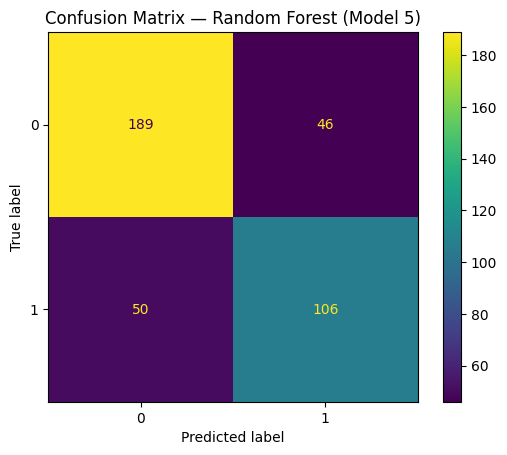

In [31]:
ConfusionMatrixDisplay.from_estimator(rf_model5, X_test, y_test)
plt.title("Confusion Matrix — Random Forest (Model 5)")
plt.show()


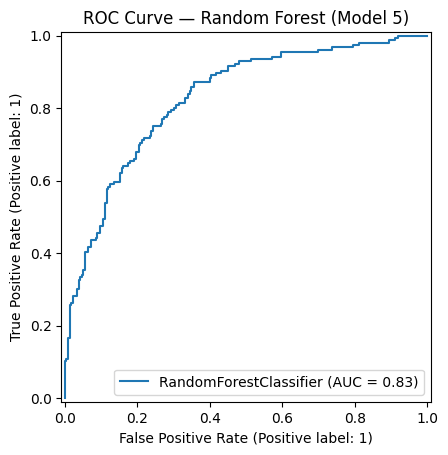

In [32]:
RocCurveDisplay.from_estimator(rf_model5, X_test, y_test)
plt.title("ROC Curve — Random Forest (Model 5)")
plt.show()

In [33]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report
)
from sklearn.model_selection import cross_val_score
import pandas as pd


y_pred_m5  = rf_model5.predict(X_test)
y_proba_m5 = rf_model5.predict_proba(X_test)[:,1]

train_acc = rf_model5.score(X_train, y_train)
test_acc  = rf_model5.score(X_test, y_test)
precision = precision_score(y_test, y_pred_m5, zero_division=0)
recall    = recall_score(y_test, y_pred_m5, zero_division=0)
f1        = f1_score(y_test, y_pred_m5)
roc_auc   = roc_auc_score(y_test, y_pred_m5)


cv_acc = cross_val_score(rf_model5, X_train, y_train, cv=5, scoring='accuracy').mean()
cv_f1  = cross_val_score(rf_model5, X_train, y_train, cv=5, scoring='f1').mean()


final_summary = pd.DataFrame([{
    "Model": "Random Forest (Model 5)",
    "Train Accuracy": train_acc,
    "Test Accuracy": test_acc,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1,
    "ROC-AUC": roc_auc,
    "CV Accuracy (mean)": cv_acc,
    "CV F1 (mean)": cv_f1
}])

print("\n=== FINAL METRICS SUMMARY — MODEL 5 ===")
print(final_summary.round(4))
print("\nClassification Report:\n", classification_report(y_test, y_pred_m5, zero_division=0))



=== FINAL METRICS SUMMARY — MODEL 5 ===
                     Model  Train Accuracy  Test Accuracy  Precision  Recall  \
0  Random Forest (Model 5)          0.8188         0.7545     0.6974  0.6795   

   F1 Score  ROC-AUC  CV Accuracy (mean)  CV F1 (mean)  
0    0.6883   0.7419              0.7702        0.7191  

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.80      0.80       235
           1       0.70      0.68      0.69       156

    accuracy                           0.75       391
   macro avg       0.74      0.74      0.74       391
weighted avg       0.75      0.75      0.75       391

